In [1]:
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.cm as cm
import seaborn as sns
import torch

import sys
sys.path.append("../")

def retime(df):
    """
    Recalculate segment time, treating the entire dataframe as one segment.

    Args:
        df (pd.DataFrame): Measurement data. Includes a column
                           'Segment Time, S'

    Returns:
        pd.DataFrame: Dataframe where 'Segment Time, S' is reindexed
                      to start from 0.
    """
    df_ = df.copy().reset_index(drop=True)
    df_["Segment Time, S"] = df_["Total Time, S"] - df_.loc[0, "Total Time, S"]
    return df_
segments_of_interest = [
    "Charge depleting cycle",
    "Charge sustaining cycle",
    'Rate test C/2 cycle charge CC',
    'PsRP 1 C/2 diagnostic cycle charge',
    'PsRP 2 C/2 diagnostic cycle charge',
    'Rate test 1C cycle charge CC',
    'PsRP 1 1C diagnostic cycle charge',
    'PsRP 2 1C diagnostic cycle charge',
]

# 1 Dataset Overview
This dataset is made up of four types of cells of a variety of chemistry types and at different states of health. 

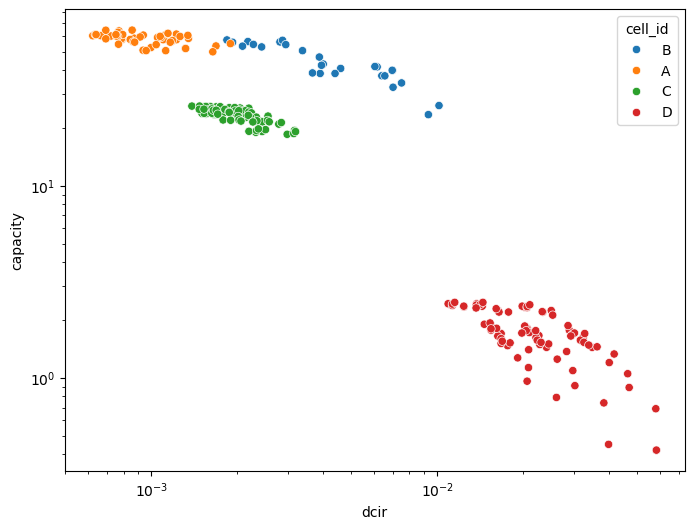

In [224]:
# hdf = pd.HDFStore('../../data/pulse_data_extracted.h5', 'r')
# keys = hdf.keys()

df_targets = pd.read_csv('../../data/targets_soh - manual volume and thickness edit.csv')
df_features = pd.read_csv('../../data/features_dcir.csv')

cell_id = df_targets['cell_id']

capacity = df_targets['C/3 discharge capacity']
dcir = (df_features['charge_resistance_10s_1C_charging'] + df_features['discharge_resistance_10s_1C_charging'])/2
temperature = df_targets['temperature_ambient']
df = pd.DataFrame({'capacity': capacity, 'dcir': dcir, 'cell_id': cell_id, 'temperature': temperature})
df.loc[df['temperature'] < 25, 'temp_category'] = '15'
df.loc[(df['temperature'] >= 25) & (df['temperature'] < 38), 'temp_category'] = '30'
df.loc[df['temperature'] >= 38, 'temp_category'] = '45'
df['cell_type'] = df['cell_id'].str[0]

fig, ax = plt.subplots(figsize=(8,6))
sns.scatterplot(x='dcir', y='capacity', data=df, hue=df['cell_id'].str[0], ax=ax)
ax.set_xscale('log')
ax.set_yscale('log')

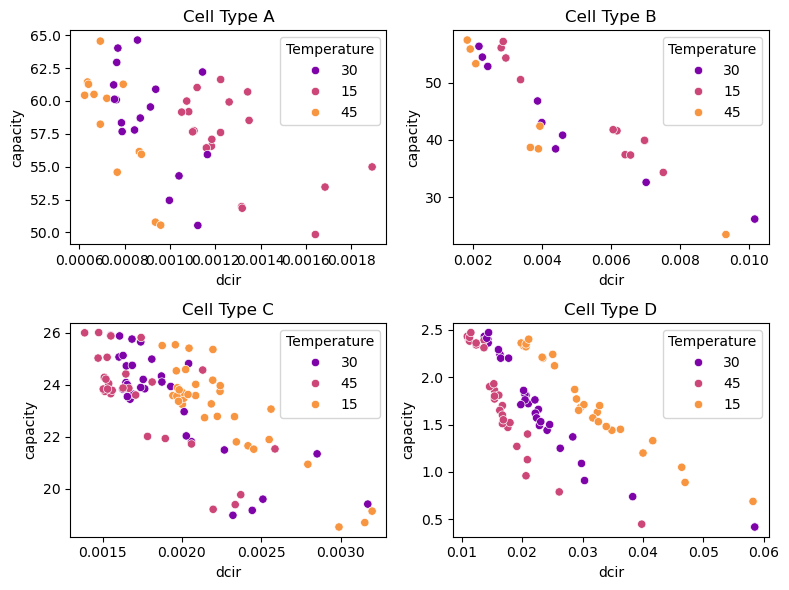

In [225]:
fig, ax = plt.subplots(2, 2, figsize=(8, 6))
ax = ax.flatten()

for i, cell_type in enumerate(['A', 'B', 'C', 'D']):
    df_sub = df[df['cell_id'].str[0] == cell_type]
    sns.scatterplot(x='dcir', y='capacity', data=df_sub, ax=ax[i], hue='temp_category', palette="plasma")
    ax[i].set_title(f'Cell Type {cell_type}')
    ax[i].legend(title='Temperature')

plt.tight_layout()

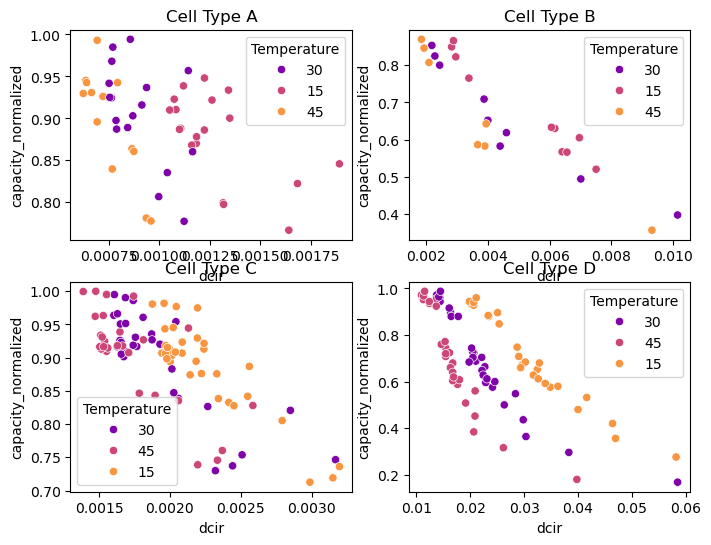

In [226]:
for type, cap in zip(['A', 'B', 'C', 'D'], [65,66,26,2.5]):
    mask = df['cell_id'].str[0] == type
    df.loc[mask, 'capacity_normalized'] = df.loc[mask, 'capacity'] / cap

fig, ax = plt.subplots(2, 2, figsize=(8, 6))
ax = ax.flatten()

for i, cell_type in enumerate(['A', 'B', 'C', 'D']):
    df_sub = df[df['cell_id'].str[0] == cell_type]
    sns.scatterplot(x='dcir', y='capacity_normalized', data=df_sub, ax=ax[i], hue='temp_category', palette="plasma")
    ax[i].set_title(f'Cell Type {cell_type}')
    ax[i].legend(title='Temperature')

C:\Users\etenney\AppData\Local\Temp\1\ipykernel_46316\3355657351.py:1: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.displot(df, x='capacity_normalized', col='cell_type', palette="plasma", facet_kws={'sharey': False}, col_wrap=2, height = 2, aspect=1.5, binwidth=0.05)


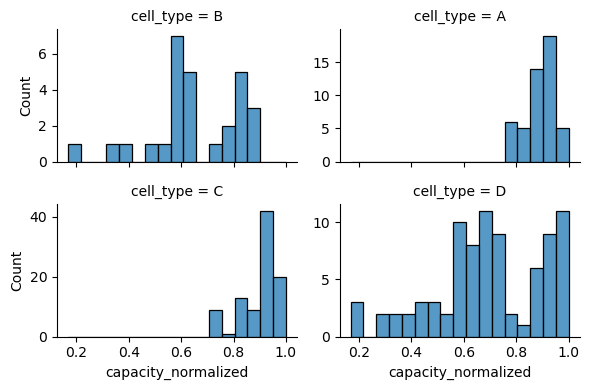

In [227]:
sns.displot(df, x='capacity_normalized', col='cell_type', palette="plasma", facet_kws={'sharey': False}, col_wrap=2, height = 2, aspect=1.5, binwidth=0.05)

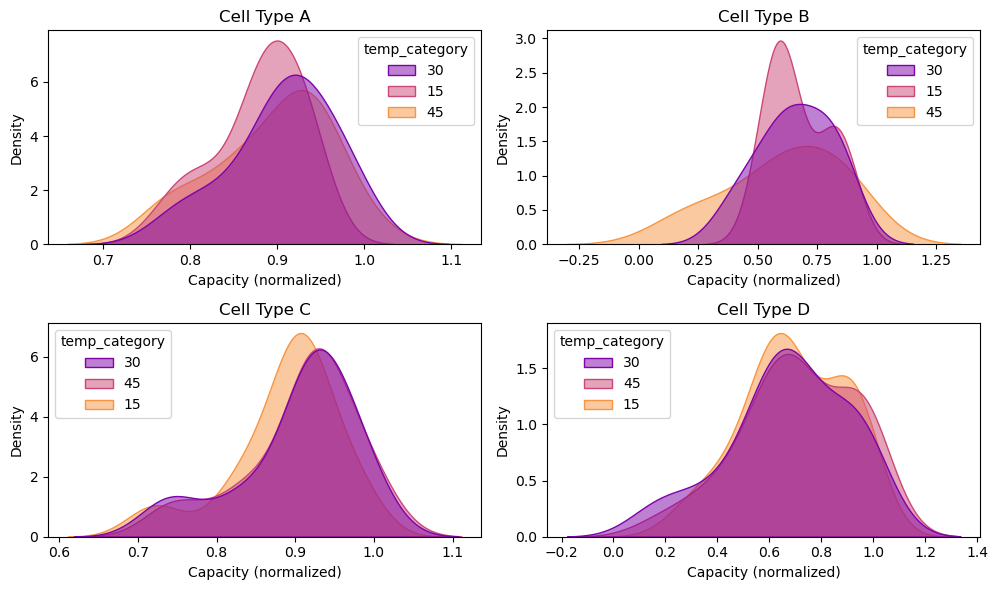

In [228]:
fig, ax = plt.subplots(2, 2, figsize=(10, 6))
ax = ax.flatten()

for i, cell_type in enumerate(['A', 'B', 'C', 'D']):
    df_sub = df[df['cell_id'].str[0] == cell_type]
    sns.kdeplot(data=df_sub, x='capacity_normalized', hue='temp_category', fill=True, common_norm=False, alpha=0.5, palette="plasma", ax=ax[i])
    ax[i].set_title(f'Cell Type {cell_type}')
    # ax[i].legend(title='Temperature')
    ax[i].set_xlabel('Capacity (normalized)')
plt.tight_layout()

# 2 Data Processing
These are the 8 segments of data that we care about. We need to process this data into a form that is useable for machine learning models

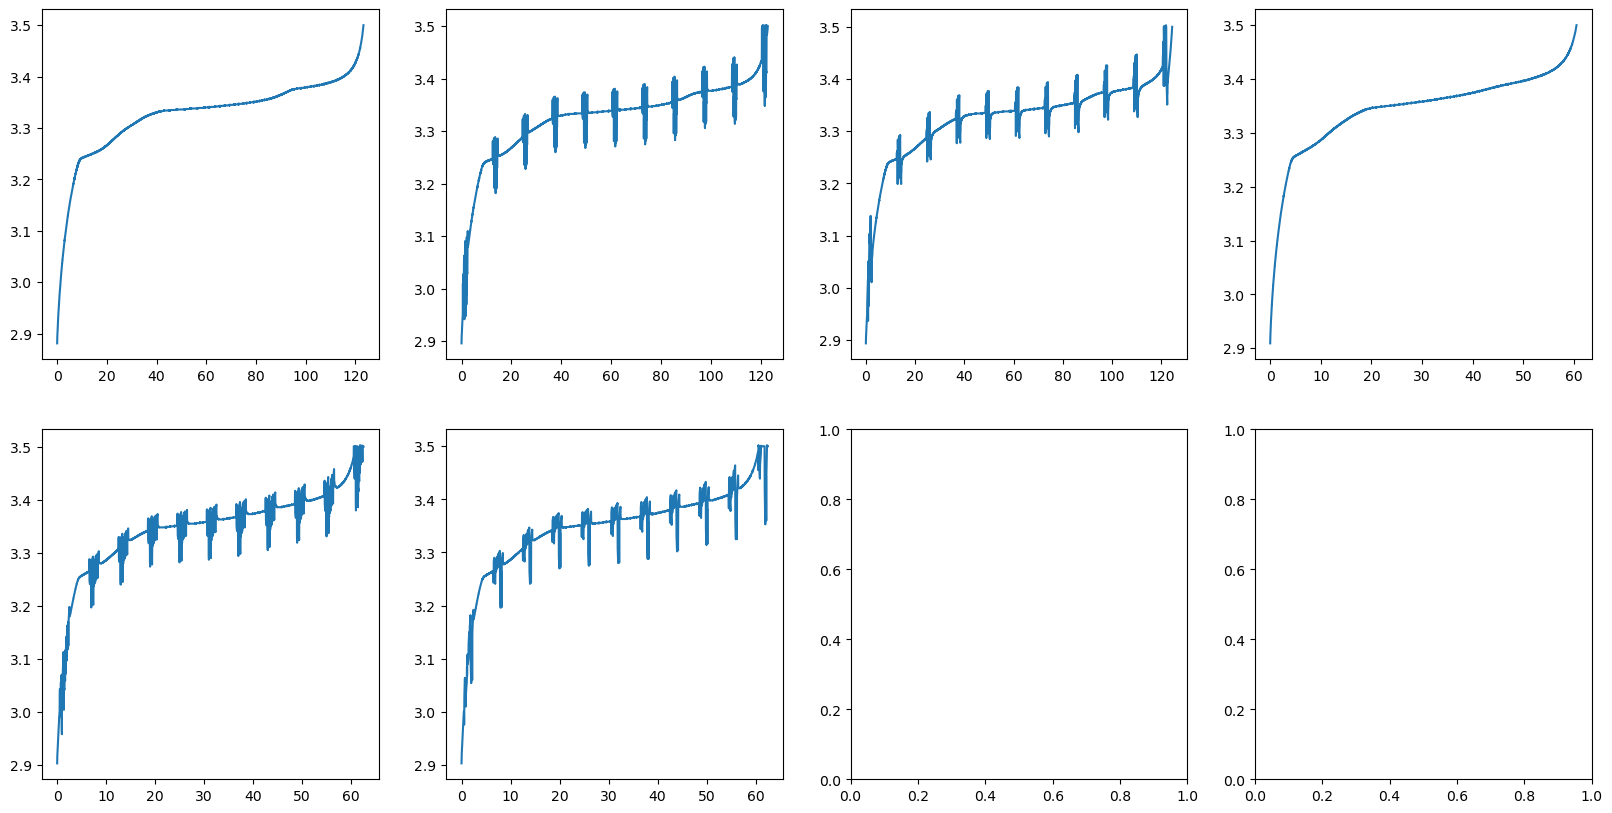

In [243]:
hdf = pd.HDFStore('../../data/data_raw.h5', 'r')
keys = hdf.keys()
df = hdf.get(keys[0])  # just get one cell for visualization
fig, ax = plt.subplots(2, 4, figsize=(20, 10))
ax = ax.flatten()
for i, segment in enumerate(segments_of_interest):
    # filter df for any rows where the col 'Segment Description' contains segment
    df_segment = df.loc[[segment in seg_desc and 'rest' not in seg_desc and 'CV' not in seg_desc for seg_desc in df['Segment Description']]]
    df_segment = retime(df_segment)
    ax[i].plot(df_segment['Segment Time, S'] / 60, df_segment['Voltage, V'])

The first is the charge depleting cycle. It is meant to mimic the drive cycle of an electric car. It repeats a consistent sequence every ten minutes until it hits a certain voltage. We can segment this data for into consistent 10 minute chunks and graph them to ensure it works correctly:

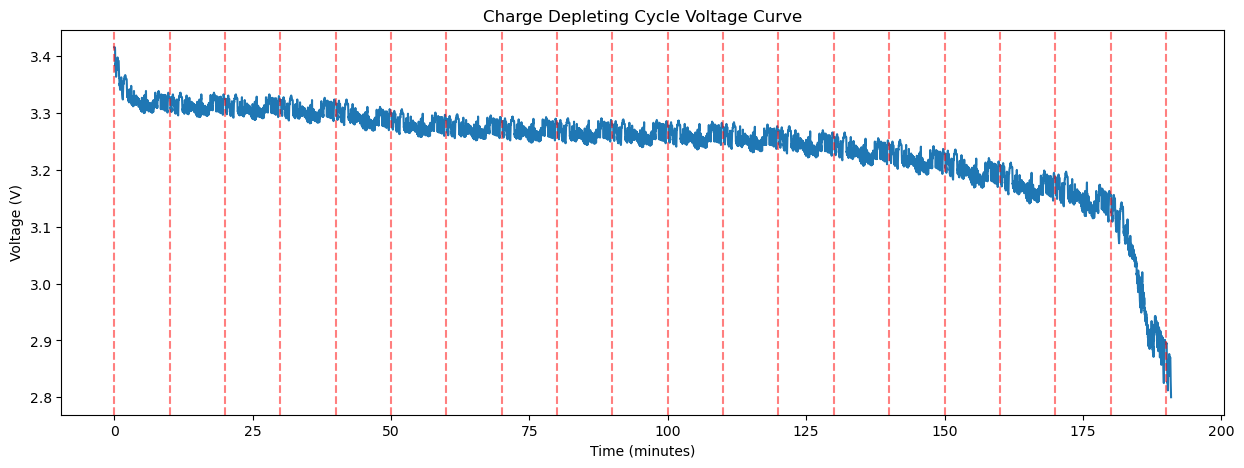

In [230]:
df = df[df['Segment Description'].str.contains('Charge depleting cycle')]

fig, ax = plt.subplots(figsize=(15,5))
ax.plot(df['Segment Time, S']/60, df['Voltage, V'])
ax.set_title('Charge Depleting Cycle Voltage Curve')
ax.set_xlabel('Time (minutes)')
ax.set_ylabel('Voltage (V)')

for _, row in df.iloc[::600, :].iterrows():
    ax.axvline(row['Segment Time, S']/60, color='red', linestyle='--', alpha=0.5)
plt.show()

In [231]:
def get_10_min_segments(df, t_length=599):
    # t_length = 599 # for whatever reason, the sequence is 599 seconds long, not 600
    df_segments = []
    _df_ = df.copy().reset_index(drop=True)
    _df_ = retime(_df_)
    _df_['Segment Time, S'] = _df_['Segment Time, S'].to_numpy().round().astype(int)
    t_start = 0
    t_end = t_length
    discontinous = False
    while t_end < _df_['Segment Time, S'].max():
        _df_segment = retime(_df_[(_df_['Segment Time, S'] >= t_start) & (_df_['Segment Time, S'] < t_end)])
        if len(_df_segment) == t_length:
            df_segments.append(_df_segment)
        elif len(_df_segment) > t_length:
            #extra data points, remove everything with a decimal in the segment time
            _df_segment = _df_segment[_df_segment['Segment Time, S'] % 1 == 0]
            if len(_df_segment) == t_length:
                print(f"removed extra data in segment starting at {t_start} seconds")
                df_segments.append(_df_segment)
            else:
                print(f"found extra data in 10 min segment starting at {t_start} seconds, unable to remove")
        else:
            print(f"found short segment starting at {t_start} seconds, only {len(_df_segment)} data points")
        t_start += t_length
        t_end += t_length
    return df_segments

C:\Users\etenney\AppData\Local\Temp\1\ipykernel_46316\476402360.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('plasma', 100)


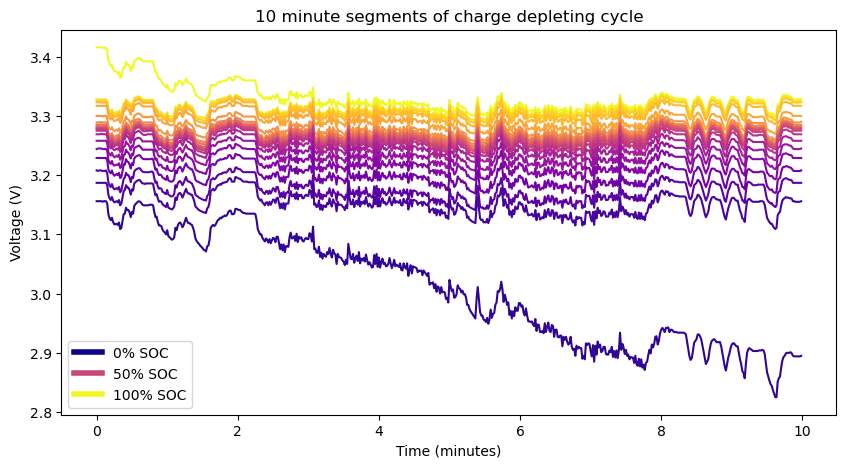

In [232]:
df_segments = get_10_min_segments(df, 600)
cmap = cm.get_cmap('plasma', 100)

fig, ax = plt.subplots(figsize=(10,5))
for segment in df_segments:
    ax.plot(segment['Segment Time, S']/60, segment['Voltage, V'], c=cmap(segment['SOC'].iloc[0]))
ax.set_title('10 minute segments of charge depleting cycle')

ax.set_xlabel('Time (minutes)')
ax.set_ylabel('Voltage (V)')

plt.legend(handles=[plt.Line2D([0], [0], color=cmap(0), lw=4, label='0% SOC'),
                    plt.Line2D([0], [0], color=cmap(49), lw=4, label='50% SOC'),
                    plt.Line2D([0], [0], color=cmap(99), lw=4, label='100% SOC')])
plt.show()

In order to prevent data leakage, we would like the training data to be completely separate from the testing data. Because of the repeating nature of the data, we can achieve this through removing the last 2 minutes of every 10 minute section and using that as training data. The training data, then, can be random 2 minute sections from the remaining 8 minutes. This way, the training and testing data segments are the same size, and there is no chance of the testing data ending up in the training process.

Text(0.5, 1.0, 'Last 2 minutes of 10 minute segments of charge depleting cycle')

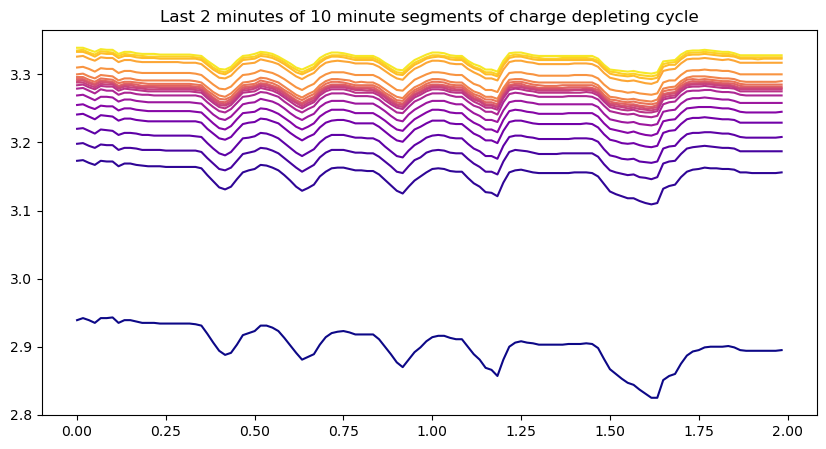

In [233]:
# get last 2 minutes of each segment for testing data
df_test_segments = []
for segment in df_segments:
    last_120s = segment[-120:]
    last_120s = retime(last_120s)
    segment.drop(segment.index[-120:], inplace=True)
    segment.reset_index(drop=True, inplace=True)
    df_test_segments.append(last_120s)

fig, ax = plt.subplots(figsize=(10,5))
for segment in df_test_segments:
    ax.plot(segment['Segment Time, S']/60, segment['Voltage, V'], c=cmap(segment['SOC'].iloc[0]))
ax.set_title('Last 2 minutes of 10 minute segments of charge depleting cycle')

Text(0.5, 1.0, 'Random 2 minute segments from the 8 minute segment')

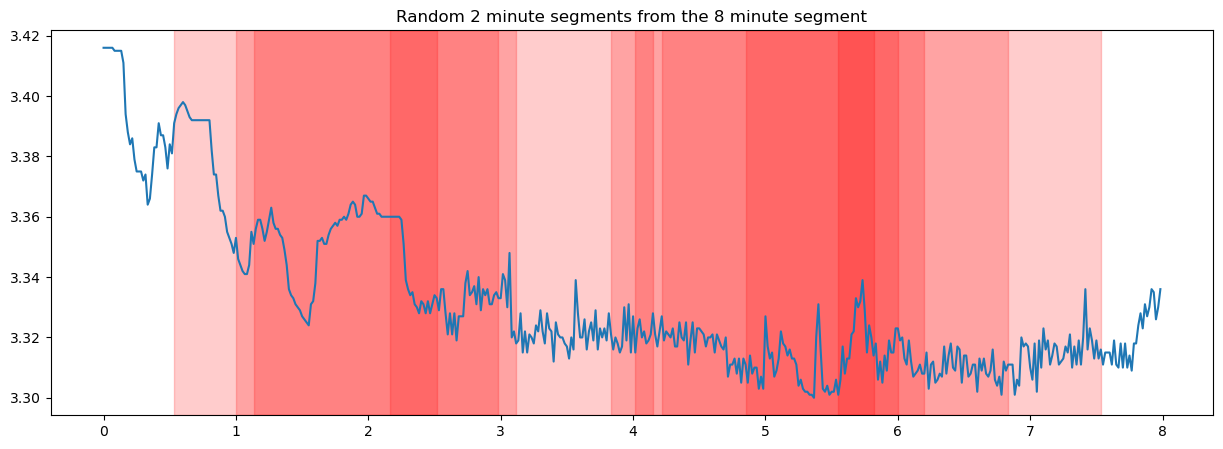

In [234]:
df_segment = df_segments[0]

import random
random.seed(1)
segment_length = 120  # 2 minutes in seconds
# select 9 random starting points for 2 minute segments
start_points = random.sample(range(0, len(df_segment) - segment_length), 9)

fig, ax = plt.subplots(figsize=(15,5))
ax.plot(df_segment['Segment Time, S']/60, df_segment['Voltage, V'])
for i in range(9):
    segment = df_segment.iloc[start_points[i]:start_points[i]+segment_length]
    ax.axvspan(segment['Segment Time, S'].iloc[0]/60, segment['Segment Time, S'].iloc[-1]/60, color='red', alpha=0.2)
ax.set_title('Random 2 minute segments from the 8 minute segment')

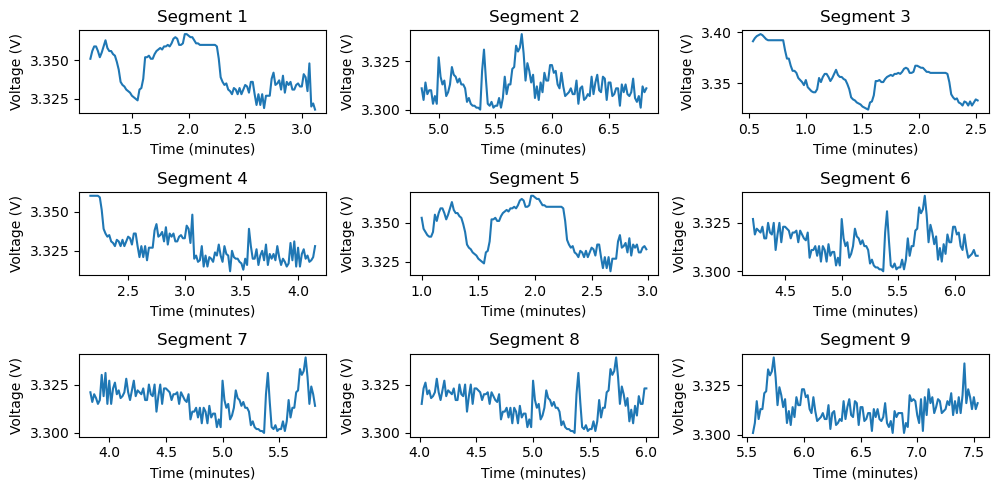

In [235]:
fig, ax = plt.subplots(3,3,figsize=(10,5))
ax = ax.flatten()

for i in range(9):
    segment = df_segment.iloc[start_points[i]:start_points[i]+segment_length]
    ax[i].plot(segment['Segment Time, S']/60, segment['Voltage, V'])
    ax[i].set_title(f'Segment {i+1}')
    ax[i].set_xlabel('Time (minutes)')
    ax[i].set_ylabel('Voltage (V)')
plt.tight_layout()

From each of these segments, we take the voltage, current, and power data for use in the model. We also save the average temperature, and the initial, final, and mean state of charge.

Text(0, 0.5, 'Power (W)')

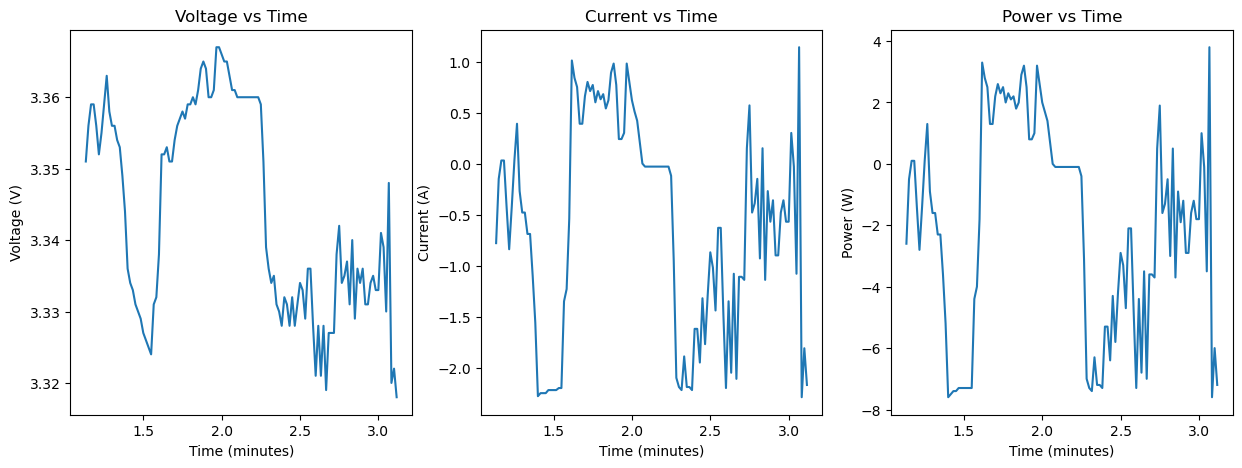

In [236]:
segment = df_segment.iloc[start_points[0]:start_points[0]+segment_length]

fig, ax = plt.subplots(1,3,figsize=(15,5))

ax[0].plot(segment['Segment Time, S']/60, segment['Voltage, V'])
ax[0].set_title('Voltage vs Time')
ax[0].set_xlabel('Time (minutes)')
ax[0].set_ylabel('Voltage (V)')

ax[1].plot(segment['Segment Time, S']/60, segment['Current, A'])
ax[1].set_title('Current vs Time')
ax[1].set_xlabel('Time (minutes)')
ax[1].set_ylabel('Current (A)')

ax[2].plot(segment['Segment Time, S']/60, segment['Power, W'])
ax[2].set_title('Power vs Time')
ax[2].set_xlabel('Time (minutes)')
ax[2].set_ylabel('Power (W)')

We do the same process for the charge sustaining cycle, which is a cycle designed to simultate a frequency-containment reserve protocol. It is a consistent 2 hour cycle across all of the batteries. Because of this, we reserve the last 30 mins for testing, and section random half hour intervals from the remaining half hour. We only get 1 testing segment from each battery measurement, but it should be mitigated by the number of measurements we have. 

Text(0.5, 0, 'Time (minutes)')

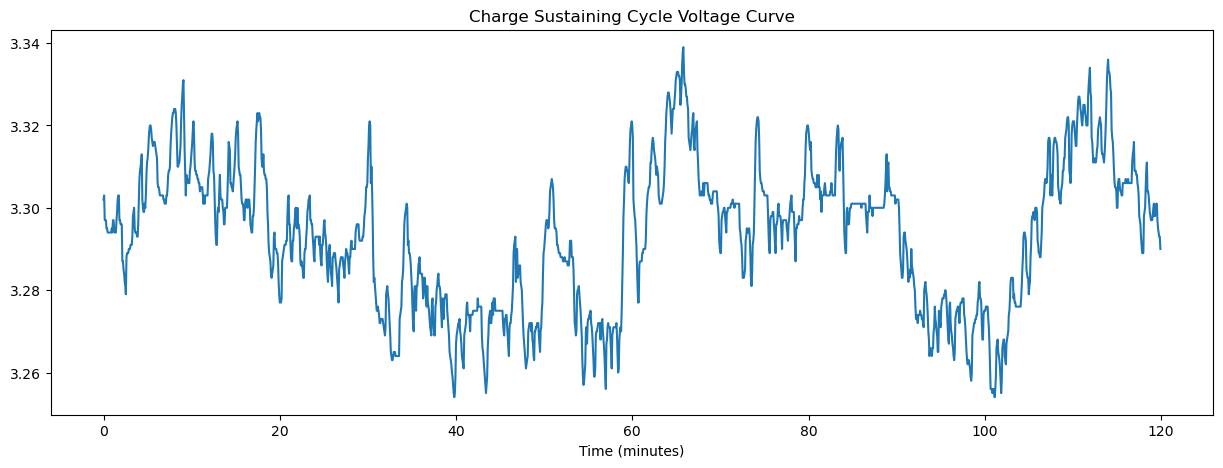

In [255]:
df = hdf.get(keys[0])
df = df[df['Segment Description'].str.contains('Charge sustaining cycle')]

fig, ax = plt.subplots(figsize=(15,5))
ax.plot(df['Segment Time, S']/60, df['Voltage, V'])
ax.set_title('Charge Sustaining Cycle Voltage Curve')
ax.set_xlabel('Time (minutes)')

Text(0.5, 1.0, 'Last 30 minutes of Charge Sustaining Cycle Voltage Curves')

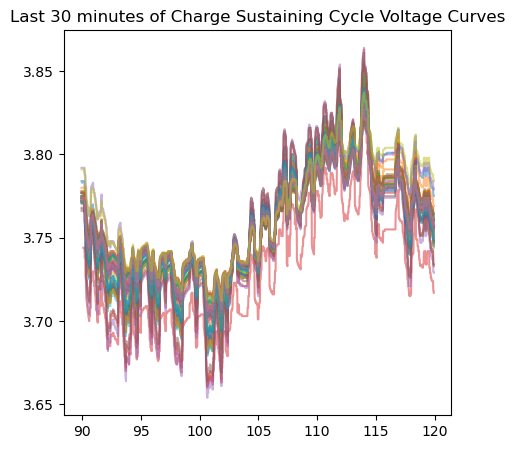

In [238]:
keys_a = [key for key in keys if "/A/" in key]

fig, ax = plt.subplots(figsize=(5,5))
for key in keys_a:
    df = hdf.get(key)
    df = df[df['Segment Description'].str.contains('Charge sustaining cycle')][-1800:]  # get last 30 minutes
    ax.plot(df['Segment Time, S']/60, df['Voltage, V'], alpha=0.5)
ax.set_title('Last 30 minutes of Charge Sustaining Cycle Voltage Curves')

The six other data segments that we care about are classified by the charging rate first, and the kind of pulse second. One of the goals of this dataset is to see if pulsing the battery allows the model to better predict targets, compared to simply charging the battery. To that end, we segment the charges into segments containing about one pulse.

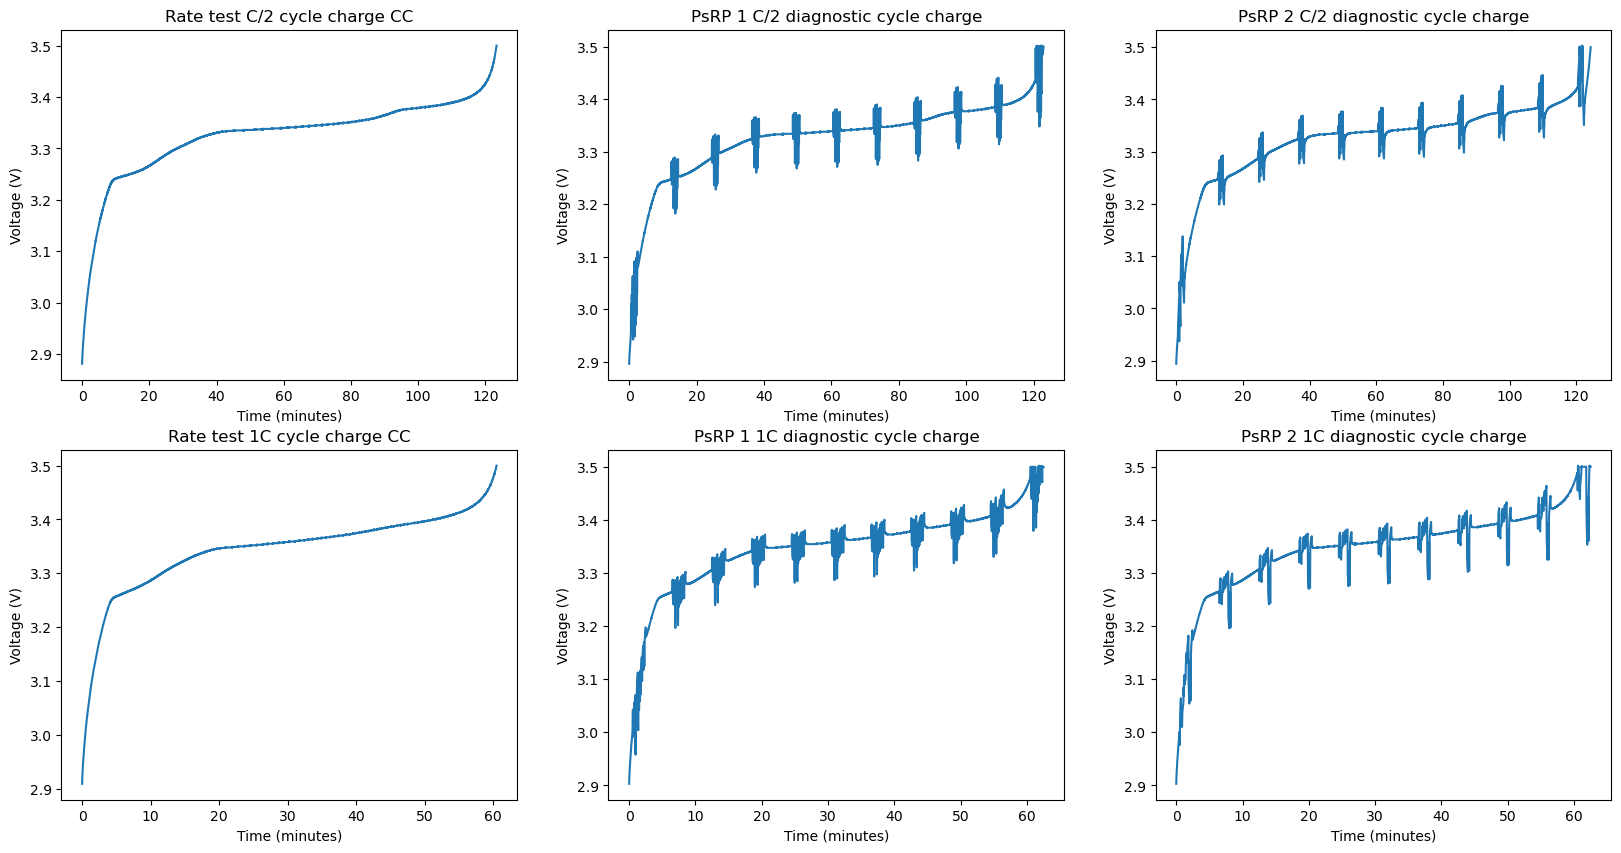

In [ ]:
df = hdf.get(keys[0])

segments_of_interest = [
    'Rate test C/2 cycle charge CC',
    'PsRP 1 C/2 diagnostic cycle charge',
    'PsRP 2 C/2 diagnostic cycle charge',
    'Rate test 1C cycle charge CC',
    'PsRP 1 1C diagnostic cycle charge',
    'PsRP 2 1C diagnostic cycle charge',
]

fig, ax = plt.subplots(2, 3, figsize=(20, 10))
ax = ax.flatten()

for i, segment in enumerate(segments_of_interest):
    # filter df for any rows where the col 'Segment Description' contains segment
    df_segment = df.loc[[segment in seg_desc and 'rest' not in seg_desc and 'CV' not in seg_desc for seg_desc in df['Segment Description']]]
    df_segment = retime(df_segment)
    ax[i].plot(df_segment['Segment Time, S'] / 60, df_segment['Voltage, V'])
    ax[i].set_title(segment)
    ax[i].set_xlabel('Time (minutes)')
    ax[i].set_ylabel('Voltage (V)')

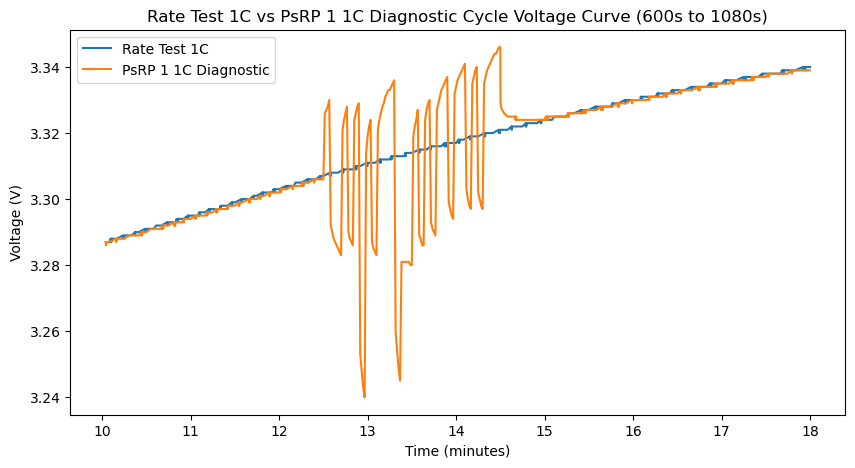

In [250]:
df_rate_test_1C = df.loc[[ 'Rate test 1C cycle charge CC' in seg_desc and 'rest' not in seg_desc and 'CV' not in seg_desc for seg_desc in df['Segment Description']]]
df_psrp1_1C = df.loc[[ 'PsRP 1 1C diagnostic cycle charge' in seg_desc and 'rest' not in seg_desc and 'CV' not in seg_desc for seg_desc in df['Segment Description']]]
df_psrp1_1C = retime(df_psrp1_1C)
fig, ax = plt.subplots(figsize=(10,5))

df_rate_test_1C = df_rate_test_1C[df_rate_test_1C['Segment Time, S'].between(600, 1080)]
df_psrp1_1C = df_psrp1_1C[df_psrp1_1C['Segment Time, S'].between(600, 1080)]

ax.plot(df_rate_test_1C['Segment Time, S']/60, df_rate_test_1C['Voltage, V'])
ax.plot(df_psrp1_1C['Segment Time, S']/60, df_psrp1_1C['Voltage, V'])

ax.set_title('Rate Test 1C vs PsRP 1 1C Diagnostic Cycle Voltage Curve (600s to 1080s)')
ax.set_xlabel('Time (minutes)')
ax.set_ylabel('Voltage (V)')

ax.legend(['Rate Test 1C', 'PsRP 1 1C Diagnostic'])


Do you notice those jumps in the data in the supposedly smooth curve? That is an artifact of the data collection process. The collection process during a pulse sampled the data every one second. When not during a pulse, it sampled the data every 5 seconds, except when it detected a change in the voltage at a millivolt scale. As such, to process this data for a model we must interpolate this data at 1 second intervals for the whole sequence. The easiest way to do this is to just take the closest point, which is ultimately the approach I followed. 

Found segment starting at 2973 seconds
Found segment starting at 118 seconds
Found segment starting at 2161 seconds
Found segment starting at 908 seconds
Found segment starting at 1793 seconds
Found segment starting at 2030 seconds
Found segment starting at 2264 seconds
Found segment starting at 954 seconds
Found segment starting at 1415 seconds


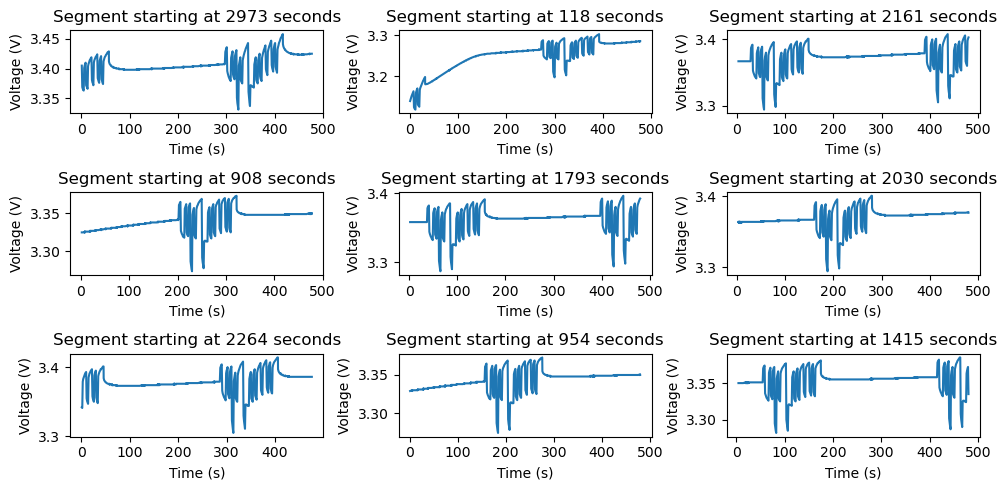

In [256]:
import random
segment_length = 480 # 8 minutes in secs
df_psrp1_1C = df.loc[[ 'PsRP 1 1C diagnostic cycle charge' in seg_desc and 'rest' not in seg_desc and 'CV' not in seg_desc for seg_desc in df['Segment Description']]]
df_psrp1_1C = retime(df_psrp1_1C)

fig, ax = plt.subplots(3, 3, figsize=(10, 5))
ax = ax.flatten()
for i in range(9):
    start_time = random.randint(0, 3600 - segment_length)

    df_segment = df_psrp1_1C[df_psrp1_1C["Segment Time, S"].between(start_time, start_time + segment_length)]
    # print(len(df_segment.columns), segment_length+1)
    # if len(df_segment.columns) == segment_length+1:
    print(f"Found segment starting at {start_time} seconds")
    ax[i].plot(df_segment['Segment Time, S'] - start_time, df_segment['Voltage, V'])

    ax[i].set_title(f'Segment starting at {start_time} seconds')
    ax[i].set_xlabel('Time (s)')
    ax[i].set_ylabel('Voltage (V)')
    # else:
    #     print(f"Segment starting at {start_time} seconds is incomplete, only {len(df_segment.columns)} data points")

fig.tight_layout()

# 3 Distribution of targets

There are two main targets we would like to be able to predict: state of charge (SOC), which is fairly easy, and discharge capacity, which is fairly hard. For example, here are some sample data segments colored by SOC, there is a clear correlation.

C:\Users\etenney\AppData\Local\Temp\1\ipykernel_46316\686961097.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('plasma', 100)


removed extra data in segment starting at 4193 seconds
removed extra data in segment starting at 4792 seconds
removed extra data in segment starting at 5391 seconds
removed extra data in segment starting at 599 seconds
removed extra data in segment starting at 1198 seconds
removed extra data in segment starting at 2396 seconds
removed extra data in segment starting at 2995 seconds
removed extra data in segment starting at 3594 seconds
removed extra data in segment starting at 4193 seconds
removed extra data in segment starting at 4792 seconds
removed extra data in segment starting at 5391 seconds
removed extra data in segment starting at 5990 seconds
removed extra data in segment starting at 6589 seconds
removed extra data in segment starting at 7188 seconds
removed extra data in segment starting at 7787 seconds
removed extra data in segment starting at 8386 seconds


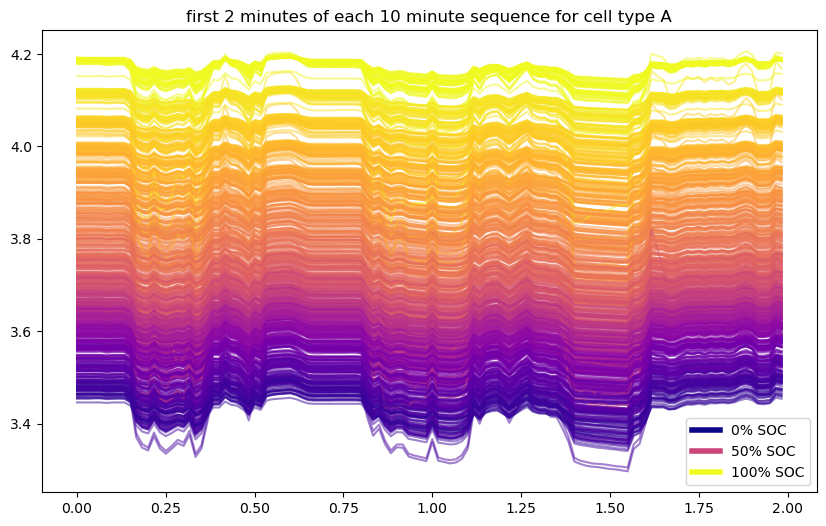

In [240]:
keys_a = [key for key in keys if "/A/" in key]
cmap = cm.get_cmap('plasma', 100)
fig, ax = plt.subplots(figsize=(10,6))
for key in keys_a:
    df = hdf.get(key)
    df = df[df['Segment Description'].str.contains('Charge depleting cycle')]
    df_segments = get_10_min_segments(df, 599)
    # plot first 120 seconds of each segment
    for segment in df_segments:
        segment = segment.head(120)
        ax.plot(segment['Segment Time, S']/60, segment['Voltage, V'], alpha=0.5, color=cmap(segment['SOC'].iloc[0]))
ax.set_title(f'first 2 minutes of each 10 minute sequence for cell type A')

plt.legend(handles=[plt.Line2D([0], [0], color=cmap(0), lw=4, label='0% SOC'),
                    plt.Line2D([0], [0], color=cmap(49), lw=4, label='50% SOC'),
                    plt.Line2D([0], [0], color=cmap(99), lw=4, label='100% SOC')])

Compare that to the same graph colored by discharge capacity. There is no clear correlation to the naked eye, which is why we are using a model to try and predict it.

Text(0, 0.5, 'Voltage (V)')

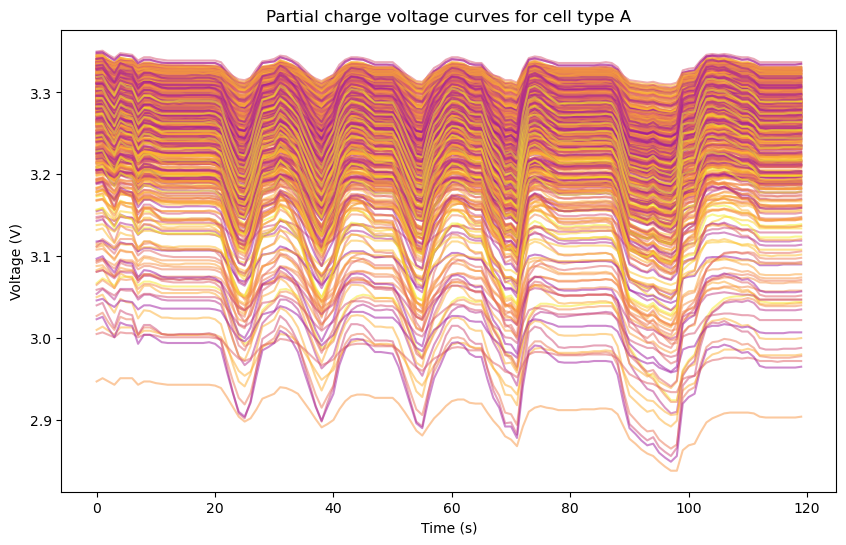

In [241]:
hdf = pd.HDFStore('../../data/data_partial_charge_for_ml.h5', 'r')
df = hdf.get('/Charge_Depleting')
df = df[df['cell_id'].str[0] == 'A']
df = df[df['split_type'] == 'testing']
fig, ax = plt.subplots(figsize=(10,6))
df['discharge_normalized'] = df['C/3 discharge capacity'] / 65  # normalize by nominal capacity
for i, row in df.iterrows():
    ax.plot(range(121), row.filter(regex='voltage'), alpha=0.5, color=cmap(row['discharge_normalized']*3-2))

ax.set_title(f'Partial charge voltage curves for cell type A')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Voltage (V)')

# plt.legend(handles=[plt.Line2D([0], [0], color=cmap(0), lw=4, label='0% capacity'),
#                     plt.Line2D([0], [0], color=cmap(49), lw=4, label='50% capacity'),
#                     plt.Line2D([0], [0], color=cmap(99), lw=4, label='100% capacity')])

# 4 Model results

Helper functions:

In [3]:
def get_metrics_all_targets(results_dict_list):
    """
    Construct a wide format df for plotting convenience
    """
    metrics = {
                'r2': [],
                'mae': [],
                'mape': [],
                'Target': [],
                'Cell ID': [],
                'Pulse Type': [],
              }
    for results_dict_soc in results_dict_list:
        for key in results_dict_soc:
            if 'features' in key:
                continue
                
            target, pulse = key.split(', ')
            if target == 'Post 1C charge relaxation fit MSE':
                continue
            df = results_dict_soc[key]
            cell_id = df['cell_id'][0][0]

            for run in range(50):
                test_subset = df[df[run].notna()]
                r2 = r2_score(test_subset[target], test_subset[run])
                mae = mean_absolute_error(test_subset[target], test_subset[run])
                mape = mean_absolute_percentage_error(test_subset[target], test_subset[run])         
                metrics[f"r2"].append(r2)
                metrics[f"mae"].append(mae)
                metrics["mape"].append(mape)
                
            metrics['Target'] += [target] * 50
            metrics['Cell ID'] += [cell_id] * 50
            metrics['Pulse Type'] += [pulse] * 50

    return pd.DataFrame(metrics)

def t(metrics, target, pulses=None):
    metrics = metrics[metrics['Target'] == target]
    if pulses is not None:
        metrics = metrics[metrics['Pulse Type'].isin(pulses)]
    return metrics

In [4]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_absolute_percentage_error, max_error, classification_report, confusion_matrix, ConfusionMatrixDisplay

def plot_true_vs_pred_axis(ax, pulse, target, result_dict, color='blue', n_splits=50, title=''):
    df = result_dict[f"{target}, {pulse}"]
    average_pred = df[list(range(n_splits))].mean(axis=1)
    sns.histplot(x=df[target],
        y=average_pred,
        stat='percent',
        bins=30,
        color=color,
        ax=ax)
    ax.axline( (df[target].min(), df[target].min()),
                       (df[target].max(), df[target].max()),
                     linestyle='dashed', color='gray')
    ax.set_title(title)
    ax.annotate("r^2: {:.3f}".format(r2_score(df[target], average_pred)), xy=(0.05, 0.9), xycoords='axes fraction', fontsize=8)

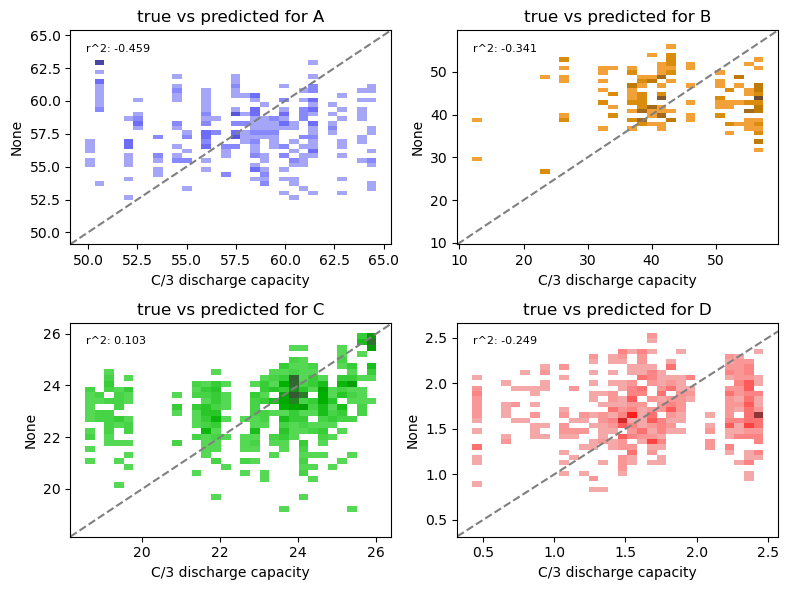

In [5]:
A_discharge = torch.load('../../results/partial_charge/capacity_no_polarization/bootstrap_results_A.pth', weights_only=False)
B_discharge = torch.load('../../results/partial_charge/capacity_no_polarization/bootstrap_results_B.pth', weights_only=False)
C_discharge = torch.load('../../results/partial_charge/capacity_no_polarization/bootstrap_results_C.pth', weights_only=False)
D_discharge = torch.load('../../results/partial_charge/capacity_no_polarization/bootstrap_results_D.pth', weights_only=False)
results_dict_list = [A_discharge, B_discharge, C_discharge, D_discharge]
metrics_discharge = get_metrics_all_targets(results_dict_list)
fig, ax = plt.subplots(2, 2, figsize=(8, 6))
plot_true_vs_pred_axis(ax[0,0], 'Rate_Test_C/2', 'C/3 discharge capacity', A_discharge, color='blue', title='true vs predicted for A')
plot_true_vs_pred_axis(ax[0,1], 'Rate_Test_C/2', 'C/3 discharge capacity', B_discharge, color='orange', title='true vs predicted for B')
plot_true_vs_pred_axis(ax[1,0], 'Rate_Test_C/2', 'C/3 discharge capacity', C_discharge, color='green', title='true vs predicted for C')
plot_true_vs_pred_axis(ax[1,1], 'Rate_Test_C/2', 'C/3 discharge capacity', D_discharge, color='red', title='true vs predicted for D')

fig.tight_layout()

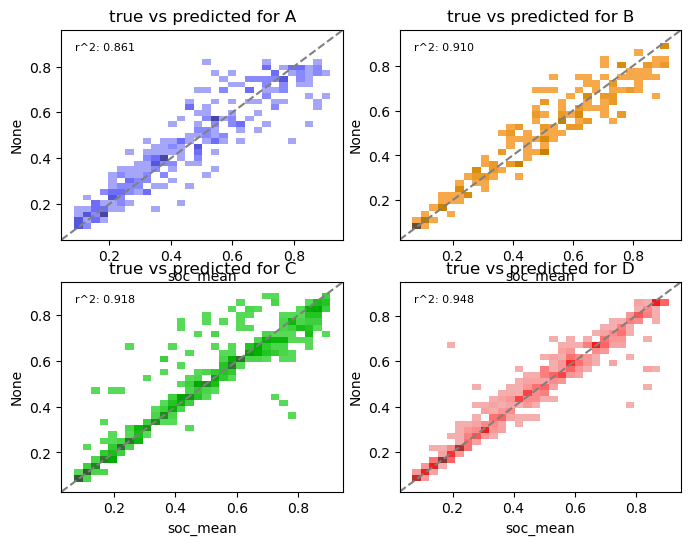

In [6]:
fig, ax = plt.subplots(2, 2, figsize=(8, 6))
A_soc = torch.load('../../results/partial_charge/soc_prediction/bootstrap_results_A.pth', weights_only=False)
B_soc = torch.load('../../results/partial_charge/soc_prediction/bootstrap_results_B.pth', weights_only=False)
C_soc = torch.load('../../results/partial_charge/soc_prediction2/bootstrap_results_C.pth', weights_only=False)
D_soc = torch.load('../../results/partial_charge/soc_prediction/bootstrap_results_D.pth', weights_only=False)

plot_true_vs_pred_axis(ax[0,0], 'Rate_Test_C/2', 'soc_mean', A_soc, color='blue', title='true vs predicted for A')
plot_true_vs_pred_axis(ax[0,1], 'Rate_Test_C/2', 'soc_mean', B_soc, color='orange', title='true vs predicted for B')
plot_true_vs_pred_axis(ax[1,0], 'Rate_Test_C/2', 'soc_mean', C_soc, color='green', title='true vs predicted for C')
plot_true_vs_pred_axis(ax[1,1], 'Rate_Test_C/2', 'soc_mean', D_soc, color='red', title='true vs predicted for D')


Text(0.5, 1.0, 'R^2 for C/3 Discharge Capacity prediction')

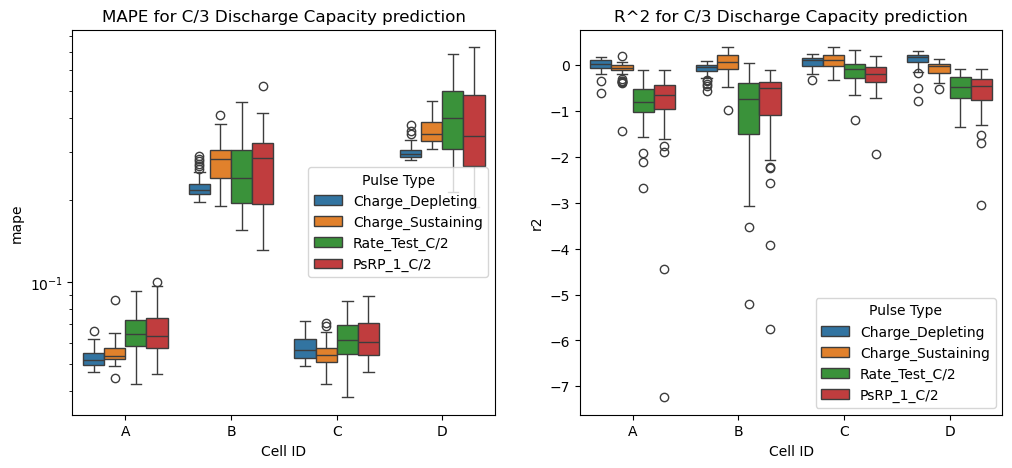

In [7]:

pulses = [
    "Charge_Depleting",
    "Charge_Sustaining",
    "Rate_Test_C/2",
    # "Rate_Test_1C",
    "PsRP_1_C/2",
    # "PsRP_1_1C",
    # "PsRP_2_C/2",
    # "PsRP_2_1C",
]

metrics_discharge = get_metrics_all_targets([A_discharge, B_discharge, C_discharge, D_discharge])
fig, ax = plt.subplots(1,2,figsize=(12, 5))
sns.boxplot(t(metrics_discharge, "C/3 discharge capacity", pulses), x='Cell ID', y='mape', hue='Pulse Type', ax=ax[0])
ax[0].set_title("MAPE for C/3 Discharge Capacity prediction")
ax[0].set_yscale('log')

sns.boxplot(t(metrics_discharge, "C/3 discharge capacity", pulses), x='Cell ID', y='r2', hue='Pulse Type', ax=ax[1])
ax[1].set_title("R^2 for C/3 Discharge Capacity prediction")
# ax[1].set_yscale('log')

Text(0.5, 1.0, 'R^2 for SOC Mean prediction')

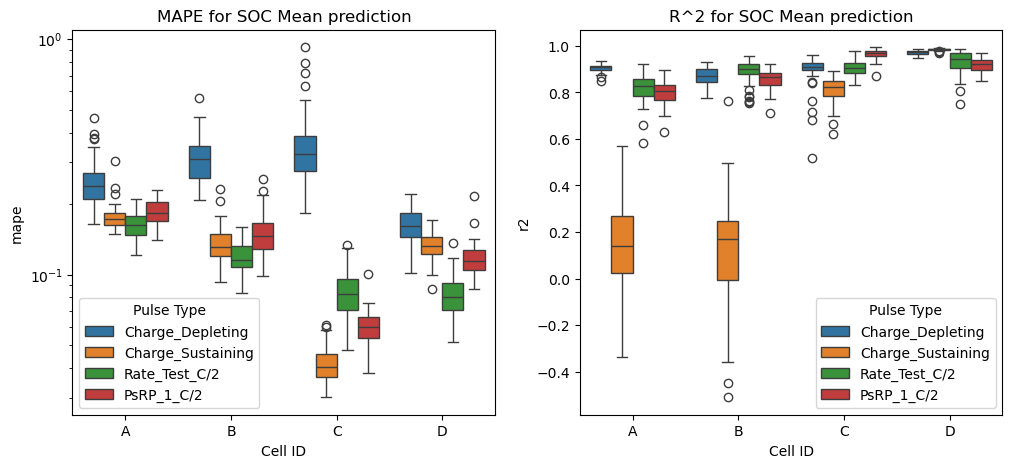

In [9]:
metrics_soc = get_metrics_all_targets([A_soc, B_soc, C_soc, D_soc])
fig, ax = plt.subplots(1,2,figsize=(12, 5))

sns.boxplot(t(metrics_soc, "soc_mean", pulses), x='Cell ID', y='mape', hue='Pulse Type', ax=ax[0])
ax[0].set_title("MAPE for SOC Mean prediction")
ax[0].set_yscale('log')

sns.boxplot(t(metrics_soc, "soc_mean", pulses), x='Cell ID', y='r2', hue='Pulse Type', ax=ax[1])
ax[1].set_title("R^2 for SOC Mean prediction")
# ax[1].set_yscale('log')

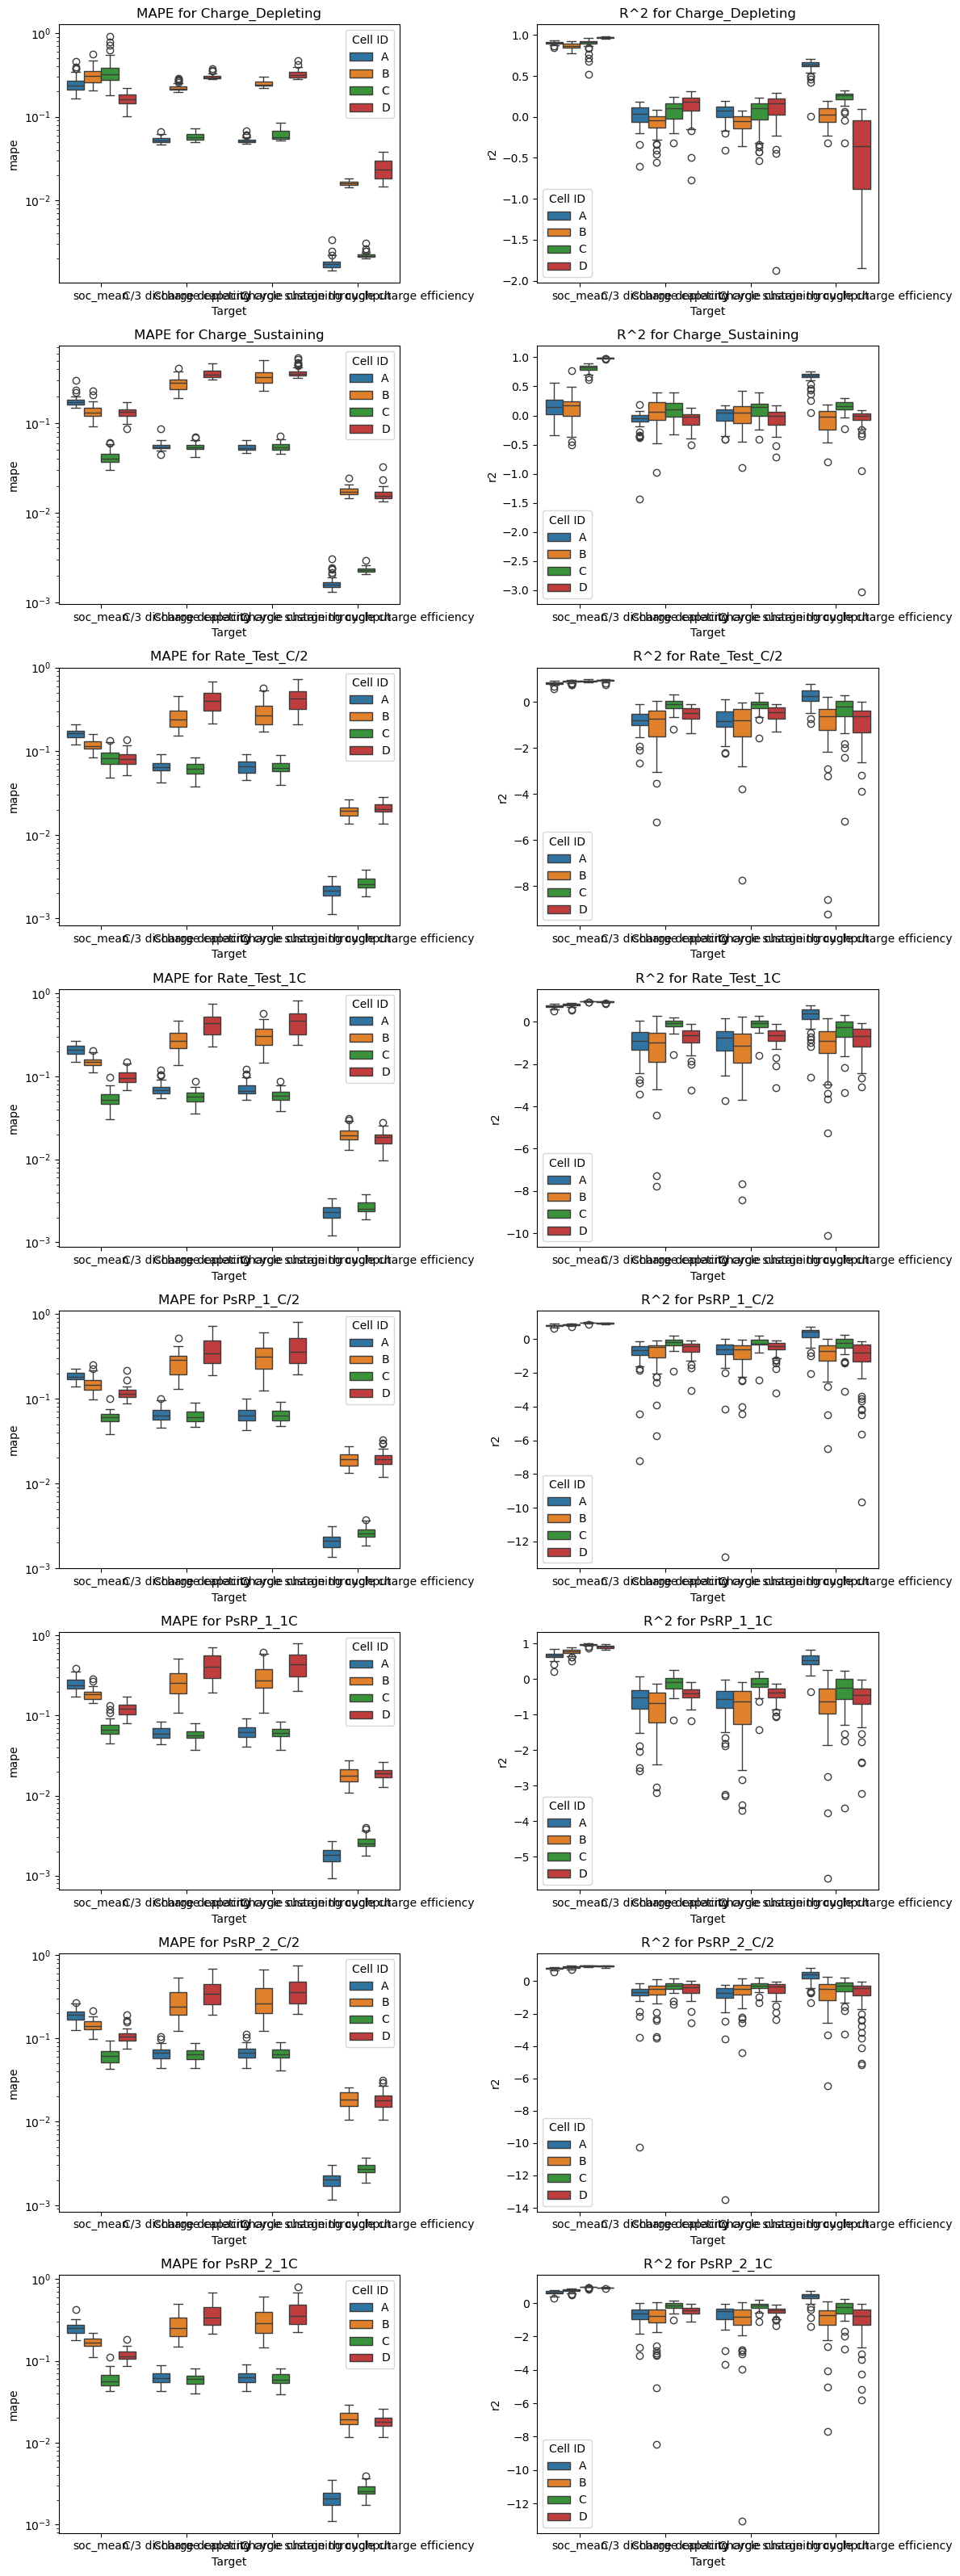

In [8]:
fig, ax = plt.subplots(8,2,figsize=(12, 32))

pulses = [
    "Charge_Depleting",
    "Charge_Sustaining",
    "Rate_Test_C/2",
    "Rate_Test_1C",
    "PsRP_1_C/2",
    "PsRP_1_1C",
    "PsRP_2_C/2",
    "PsRP_2_1C",
]

A_us06 = torch.load('../../results/partial_charge/us06_fcr_cycle/bootstrap_results_A.pth', weights_only=False)
B_us06 = torch.load('../../results/partial_charge/us06_fcr_cycle/bootstrap_results_B.pth', weights_only=False)
C_us06 = torch.load('../../results/partial_charge/us06_fcr_cycle/bootstrap_results_C.pth', weights_only=False)
D_us06 = torch.load('../../results/partial_charge/us06_fcr_cycle/bootstrap_results_D.pth', weights_only=False)

# metrics = get_metrics_all_targets([A_soc, B_soc, C_soc, D_soc, A_discharge, B_discharge, C_discharge, D_discharge])
metrics = get_metrics_all_targets([A_soc, B_soc, C_soc, D_soc, A_discharge, B_discharge, C_discharge, D_discharge, A_us06, B_us06, C_us06, D_us06])

for i,pulse in enumerate(pulses):
    sns.boxplot(metrics[metrics['Pulse Type'] == pulse], x='Target', y='mape', hue='Cell ID', ax=ax[i,0])
    ax[i,0].set_title(f"MAPE for {pulse}")
    ax[i,0].set_yscale('log')

    sns.boxplot(metrics[metrics['Pulse Type'] == pulse], x='Target', y='r2', hue='Cell ID', ax=ax[i,1])
    ax[i,1].set_title(f"R^2 for {pulse}")

# sns.boxplot(metrics[metrics['Pulse Type'] == 'Rate_Test_C/2'], x='Target', y='mape', hue='Cell ID', ax=ax[0])
# ax[0].set_title("MAPE for Rate Test C/2")
# ax[0].set_yscale('log')

# sns.boxplot(metrics[metrics['Pulse Type'] == 'Rate_Test_C/2'], x='Target', y='r2', hue='Cell ID', ax=ax[1])
# ax[1].set_title("R^2 for Rate Test C/2")

# sns.boxplot(metrics[metrics['Pulse Type'] == 'Charge_Depleting'], x='Target', y='mape', hue='Cell ID', ax=ax[2])
# ax[2].set_title("MAPE for Charge Depleting")

# ax[2].set_yscale('log')

fig.tight_layout()

In [51]:
def get_true_pred_metadata(result_dict, target, pulses):
    """
    Helper function to plot systematic errors due to metadata.
    """
    true, pred = [], []
    temp, rate, soc = [], [], []
    iteration = []
    mae = []
    
    for pulse in pulses:
        df = result_dict[f"{target}, {pulse}"]
        for i in range(50):
            subset = df[df[i].notna()]
            true += subset[target].to_list()
            pred += subset[i].to_list()
            temp += subset['temperature_ambient'].to_list()
            if 'rate' in subset:
                rate += subset['rate'].to_list()
            else:
                rate += [np.nan] * len(subset)
            if 'soc_mean' in subset:
                soc += subset['soc_mean'].to_list()
            else:
                soc += [np.nan] * len(subset)
            iteration += [i] * len(subset)
            mae += [mean_absolute_error(subset[target], subset[i])] * len(subset)
    
    residual = np.array(true) - np.array(pred)
    return pd.DataFrame({"True": true, f"Predicted": pred,
                         "Residual": residual,
                         "MAE": mae,
                         'Temperature': temp, 'C-rate': rate,
                         'SOC': soc, "Iteration": iteration})

def plot_errors(df, target, cell_id):
    
    df_metadata = get_true_pred_metadata(df, target, ['Charge_Depleting',])
#     df_metadata = df_metadata.replace("C/10", 0.10)
#     df_metadata = df_metadata.replace("C/2", 0.5)
#     df_metadata = df_metadata.replace("1C", 1)
#     df_metadata = df_metadata.replace("2C", 2)

    
    fig, axes = plt.subplots(1, 2, figsize=(8,4))
    axes = axes.ravel()
    
    # Effect of temperature
    sns.histplot(df_metadata, x='Temperature', y='Residual', ax=axes[0])
    axes[0].hlines(xmin=axes[0].get_xlim()[0], xmax=axes[0].get_xlim()[1], y=0, linestyle='dashed', color='grey')
    axes[0].set_ylabel("Residual (Ah)")
    
    # Effect of rate
#     # v1
#     df_metadata['abs(Residual)'] = abs(df_metadata['Residual'])
#     m = df_metadata.groupby('C-rate').mean().loc[['C/2', '1C']]
#     yerr = df_metadata.groupby('C-rate').std().loc[['C/2', '1C']]
#     axes[1].errorbar(m.index, m['abs(Residual)'], fmt='o', yerr=yerr['abs(Residual)'], capsize=5)   
#     axes[1].set_xlabel("C-rate") # , size='xx-large')
#     axes[1].set_ylabel("MAE (Ah)") # , size='xx-large')
# #     axes[1].set_xticklabels(axes[1].get_xticklabels(), size='xx-large')
# #     axes[1].set_yticklabels(axes[1].get_yticklabels(), size='xx-large')
    # axes[2].errorbar(m.index, m['abs(Residual)'], fmt='o')
    
    # Effect of SOC
    sns.histplot(df_metadata, x='SOC', y='Residual', ax=axes[1])
    axes[1].hlines(xmin=0, xmax=1, y=0, linestyle='dashed', color='grey')
    axes[1].set_ylabel("Residual (Ah)")
    
    fig.tight_layout()
    return fig

In [50]:
df_metadata_A = get_true_pred_metadata(A_discharge, 'C/3 discharge capacity', ['Charge_Depleting',])

df_metadata_A



,True,Predicted,Residual,MAE,Temperature,C-rate,SOC,Iteration
0,64.02,59.480259,4.539741,2.641180,31.0,NaN,NaN,0
1,64.02,59.454960,4.565040,2.641180,31.0,NaN,NaN,0
2,64.02,59.683727,4.336273,2.641180,31.0,NaN,NaN,0
3,64.02,58.378979,5.641021,2.641180,31.0,NaN,NaN,0
4,64.02,60.713573,3.306427,2.641180,31.0,NaN,NaN,0
...,...,...,...,...,...,...,...,...
29445,64.55,60.383881,4.166119,2.762492,46.0,NaN,NaN,49
29446,64.55,59.940006,4.609994,2.762492,46.0,NaN,NaN,49
29447,64.55,59.137215,5.412785,2.762492,46.0,NaN,NaN,49
29448,64.55,61.328503,3.221497,2.762492,46.0,NaN,NaN,49


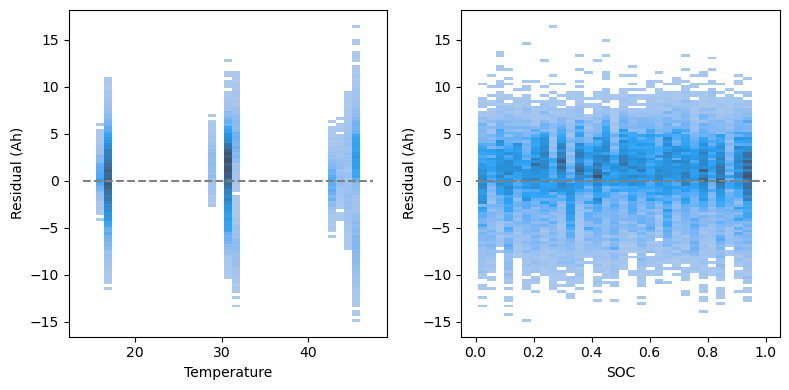

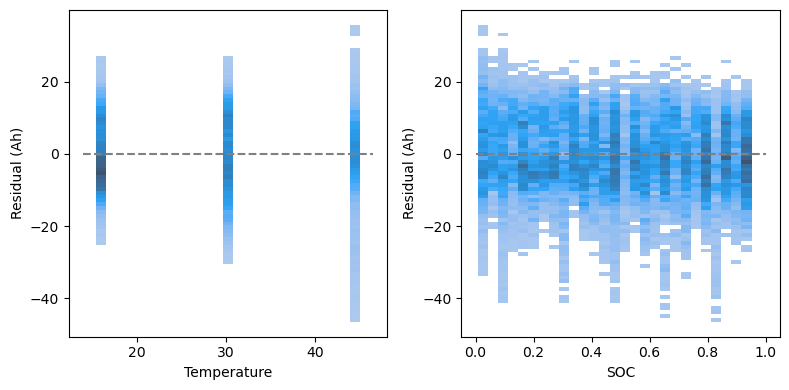

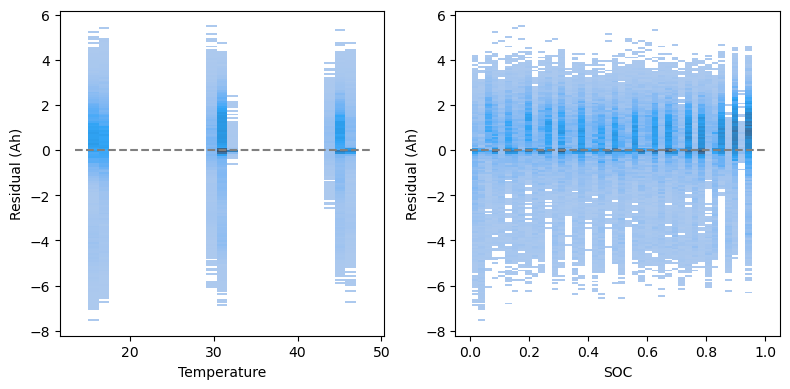

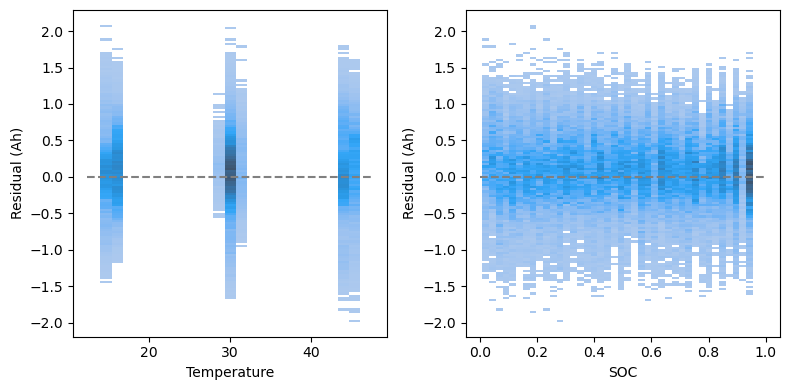

In [53]:
fig = plot_errors(A_discharge, 'C/3 discharge capacity', 'A')
# fig.savefig("systematic_errors_c_1c.png")

fig = plot_errors(B_discharge, 'C/3 discharge capacity', 'B')
fig = plot_errors(C_discharge, 'C/3 discharge capacity', 'C')
fig = plot_errors(D_discharge, 'C/3 discharge capacity', 'D')

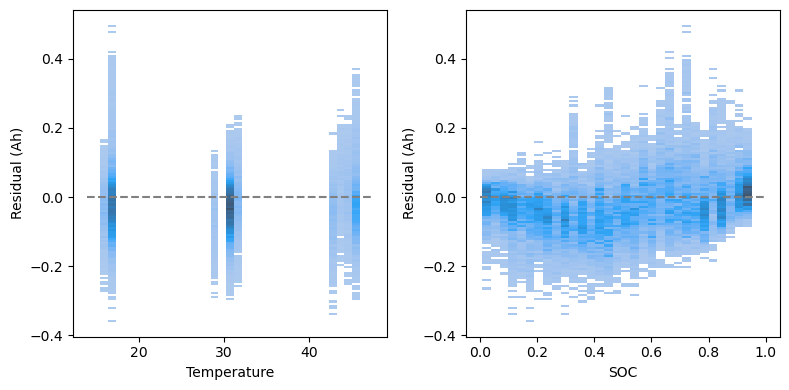

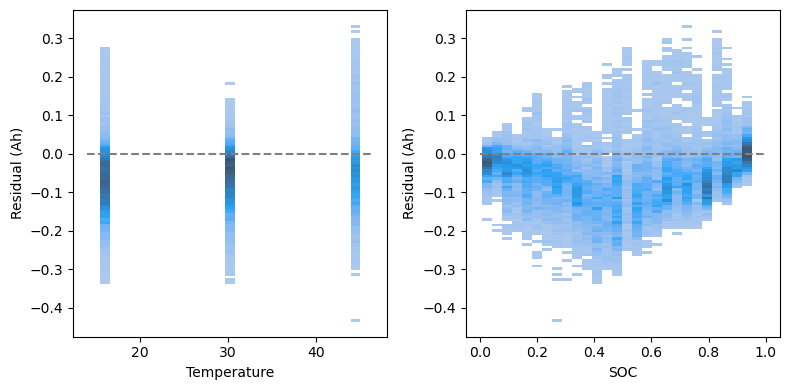

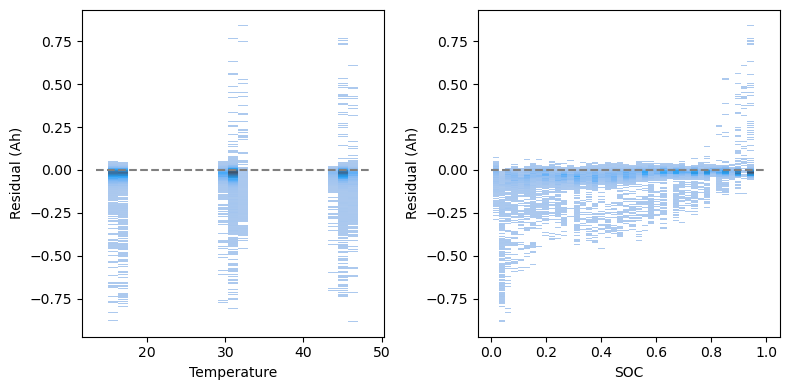

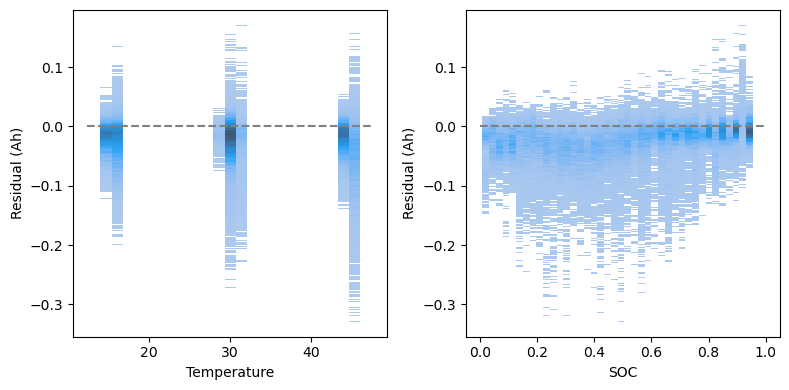

In [54]:
fig = plot_errors(A_soc, 'soc_mean', 'A')
fig = plot_errors(B_soc, 'soc_mean', 'B')
fig = plot_errors(C_soc, 'soc_mean', 'C')
fig = plot_errors(D_soc, 'soc_mean', 'D')

C/3 discharge capacity
soc_mean


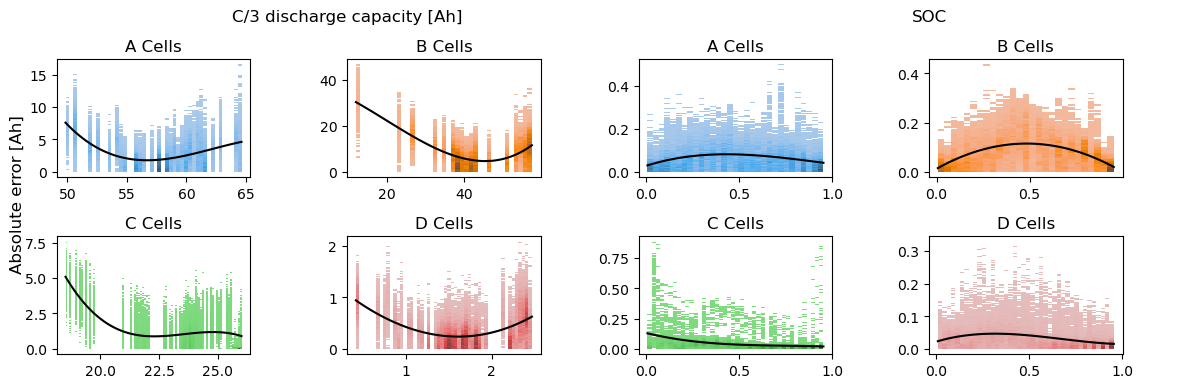

In [58]:
titles = {
    # 'Charge depleting cycle charge throughput': 'US06 Cycle\nCharge Throughput',
    # 'Charge sustaining cycle charge efficiency': 'FCR Cycle\nCharge Efficiency',
    'soc': 'SOC',
    'C/3 discharge capacity': 'C/3 discharge capacity [Ah]',
}

colors = {
    "A": (50/225, 116/225, 161/225),
    "B": (225/225, 129/225, 44/225),
    "C": (58/225, 146/225, 58/225),
    "D": (192/225, 61/225, 62/225),
}

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF

def plot_abs_error_vs_soh(results_list, target, pulse, ax):
    print(target)
    X, y = [], []
    for results in results_list:
        df = results[f"{target}, {pulse}"]
        for i in range(50):
            chunk = df[df[i].notna()]
            abs_error = abs(chunk[target] - chunk[i])
            X += chunk[target].values.tolist()
            y += abs_error.values.tolist()
    ax.scatter(X, y, color='tab:blue')

    z = np.poly1d(np.polyfit(X, y, 3))
    X_pred = np.linspace(min(X), max(X), 100).reshape(-1, 1)
    y_pred = z(X_pred)
    
    ax.plot(X_pred, y_pred, color='tab:orange', label='Polynomial fit (d=3)')
    ax.set_xlabel(f"{titles[target]}")
    ax.legend()
    
def plot_abs_error_vs_soh_cells_separate(results_list, cell_type_names_list, target, pulse, ax):
    
    print(target)

    ax.axis('off')
    ax_0 = ax.inset_axes([-0.1, 0.5, 0.4, 0.4])
    ax_1 = ax.inset_axes([0.5, 0.5, 0.4, 0.4])
    ax_2 = ax.inset_axes([-0.1, -0.1, 0.4, 0.4])
    ax_3 = ax.inset_axes([0.5, -0.1, 0.4, 0.4])
    
    axes = [ax_0, ax_1, ax_2, ax_3]
    
    for j, results in enumerate(results_list):
        X, y = [], []
        df = results[f"{target}, {pulse}"]
        for i in range(50):
            chunk = df[df[i].notna()]
            abs_error = abs(chunk[target] - chunk[i])
            X += chunk[target].values.tolist()
            y += abs_error.values.tolist()
        sns.histplot(ax=axes[j], x=X, y=y, color=colors[cell_type_names_list[j]])
        axes[j].set_title(f"{cell_type_names_list[j]} Cells")

        n = 3
        pfit, cov = np.polyfit(X, y, 3, cov=True)
        uncertainty = np.sqrt(np.diag(cov))
        z = np.poly1d(pfit)
        X_pred = np.linspace(min(X), max(X), 100)
        y_pred = z(X_pred.reshape(-1, 1))
        
        TT = np.vstack([X_pred**(n-i) for i in range(n+1)]).T
        yi = np.dot(TT, pfit)  # matrix multiplication calculates the polynomial values
        C_yi = np.dot(TT, np.dot(cov, TT.T)) # C_y = TT*C_z*TT.T
        sig_yi = np.sqrt(np.diag(C_yi))  # Standard deviations are sqrt of diagonal
      
        axes[j].plot(X_pred, y_pred, color='black', label='Polynomial fit (d=3)')

pulse = "Charge_Depleting"
fig, ax = plt.subplots(1,2, figsize=(12,4))
targets = ["C/3 discharge capacity"]
ax = ax.ravel()
for i, target in enumerate(targets):
    plot_abs_error_vs_soh_cells_separate([A_discharge, B_discharge, C_discharge, D_discharge], ['A', 'B', 'C', 'D'], target, pulse, ax[i])
    ax[i].set_title(titles[target])
    ax[i].set_xlabel(titles[target])
    ax[i].set_ylabel("Absolute error")
plot_abs_error_vs_soh_cells_separate([A_soc, B_soc, C_soc, D_soc], ['A', 'B', 'C', 'D'], 'soc_mean', pulse, ax[-1])
ax[-1].set_title("SOC")
fig.supylabel("Absolute error [Ah]")
fig.tight_layout()
plt.show()